In [2]:
#https://drive.google.com/file/d/1wH0Hqc_UhjovQ6J9tCr4nu_lQZZCx-QI/view?usp=sharing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
id = '1wH0Hqc_UhjovQ6J9tCr4nu_lQZZCx-QI'
url = f'https://drive.google.com/uc?id={id}'
df = pd.read_csv(url)
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,03-01-2012,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,04-01-2012,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,05-01-2012,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,06-01-2012,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,09-01-2012,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


#Data Preprocessing

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2011 non-null   object 
 1   Open       2011 non-null   float64
 2   High       2011 non-null   float64
 3   Low        2011 non-null   float64
 4   Close      2011 non-null   float64
 5   Adj Close  2011 non-null   float64
 6   Volume     2011 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 110.1+ KB


'Date' column is in object datatype. Convert it into datetime datatype

In [3]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2011 non-null   datetime64[ns]
 1   Open       2011 non-null   float64       
 2   High       2011 non-null   float64       
 3   Low        2011 non-null   float64       
 4   Close      2011 non-null   float64       
 5   Adj Close  2011 non-null   float64       
 6   Volume     2011 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 110.1 KB


###Handling missing values:

In [5]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

No missing values in the dataset

In [6]:
df.set_index('Date', inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


###Feature engineering:


Engineer new features such as 30-day Simple Moving Averages (SMA), 7-day Exponential Moving Averages (EMA) for the 'Close' price to capture long-term and short-term trends, and calculate daily volatility as the daily percentage change in 'Close' price.

In [7]:
df['SMA 30'] = df['Close'].rolling(window=30).mean()
df['EMA 7'] = df['Close'].ewm(span=7, adjust=False).mean()
df['Daily Volatility'] = df['Close'].pct_change()
df.head()

,Open,High,Low,Close,Adj Close,Volume,SMA 30,EMA 7,Daily Volatility
Date,,,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,NaN,58.747143,NaN
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,NaN,58.826072,0.005374
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,NaN,59.049197,0.011102
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,NaN,59.372612,0.010454
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,NaN,59.591245,-0.001586


###Handling NaN values in newly engineered features:

In [8]:
df.fillna(0, inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume,SMA 30,EMA 7,Daily Volatility
Date,,,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,0.0,58.747143,0.000000
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,0.0,58.826072,0.005374
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,0.0,59.049197,0.011102
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,0.0,59.372612,0.010454
2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,0.0,59.591245,-0.001586


###Normalization:


In [9]:
from sklearn.preprocessing import MinMaxScaler

scaled_df = df.copy()
scaler = MinMaxScaler()

for column in scaled_df.columns:
    scaled_df[column] = scaler.fit_transform(scaled_df[[column]])

scaled_df.head()

,Open,High,Low,Close,Adj Close,Volume,SMA 30,EMA 7,Daily Volatility
Date,,,,,,,,,
2012-01-03,0.012989,0.007780,0.014647,0.012545,0.007663,0.175791,0.0,0.004561,0.581999
2012-01-04,0.013353,0.009094,0.014819,0.013884,0.008797,0.146901,0.0,0.004907,0.607313
2012-01-05,0.016353,0.011428,0.016896,0.016666,0.011152,0.154601,0.0,0.005883,0.634293
2012-01-06,0.019274,0.013961,0.020910,0.019314,0.013394,0.186794,0.0,0.007298,0.631240
2012-01-09,0.022747,0.016976,0.022216,0.018908,0.013051,0.238641,0.0,0.008254,0.574527


# Exploratory Data Analysis

### Time Series Plots



Visualize the 'Close' price, 30-day Simple Moving Average (SMA), and 7-day Exponential Moving Average (EMA) over time to observe trends and patterns.


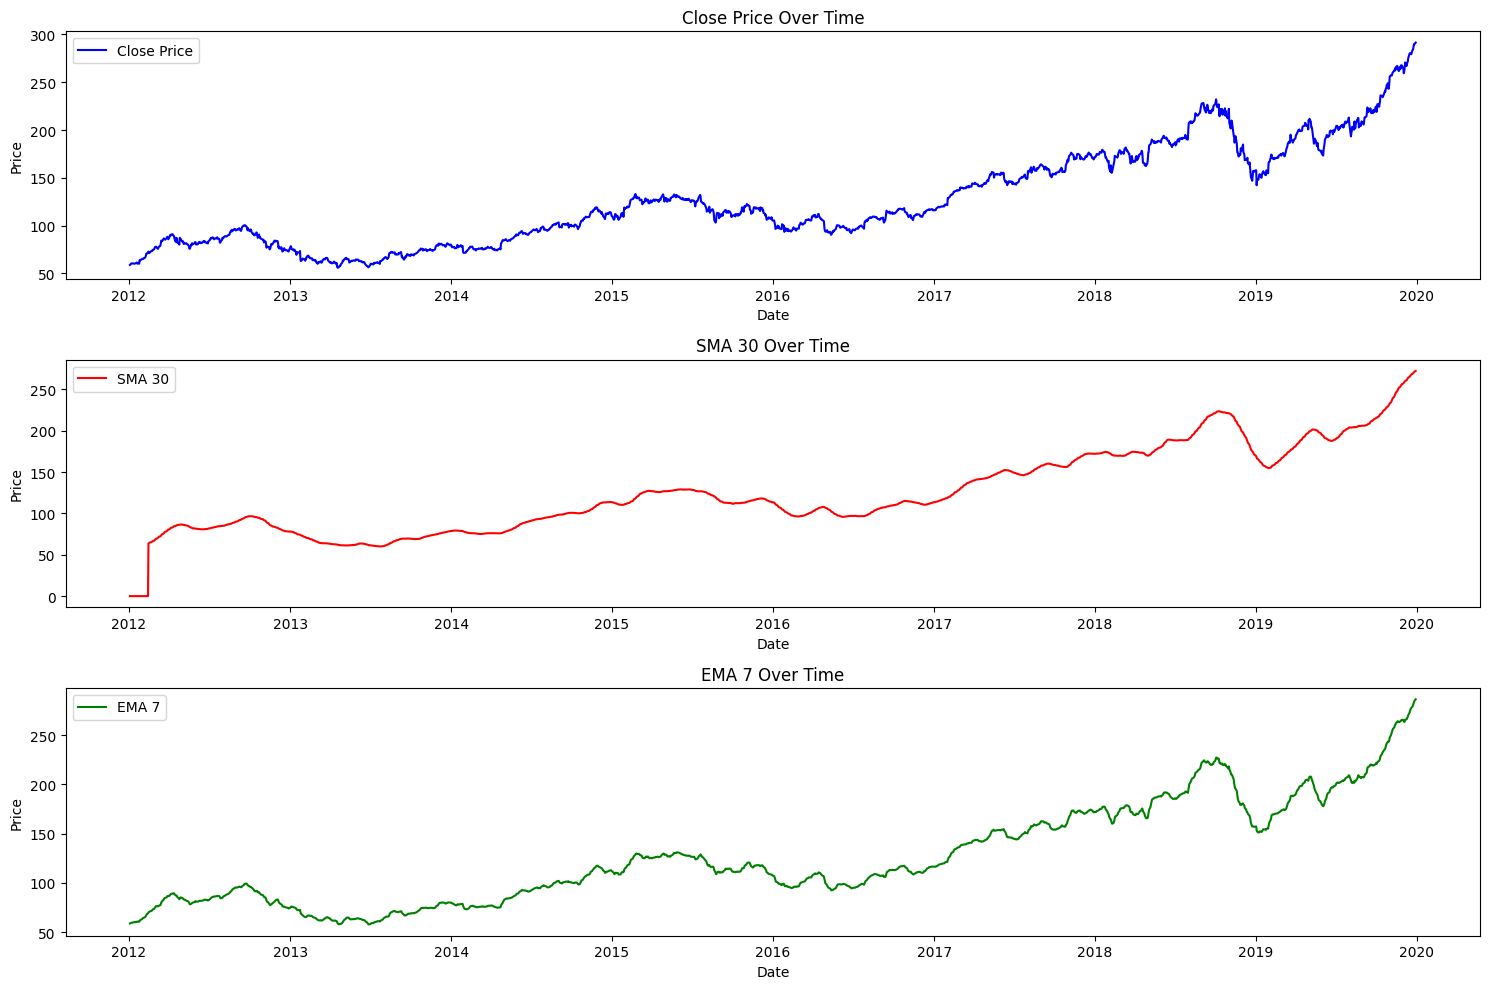

In [10]:
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.plot(df['Close'], label='Close Price', color='blue')
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(df['SMA 30'], label='SMA 30', color='red')
plt.title('SMA 30 Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(df['EMA 7'], label='EMA 7', color='green')
plt.title('EMA 7 Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.tight_layout()
plt.show()

### Correlation Analysis

Generate a heatmap to visualize the correlation matrix between all numerical features in the `df` DataFrame. This will help in understanding the relationships and dependencies between different stock price indicators.

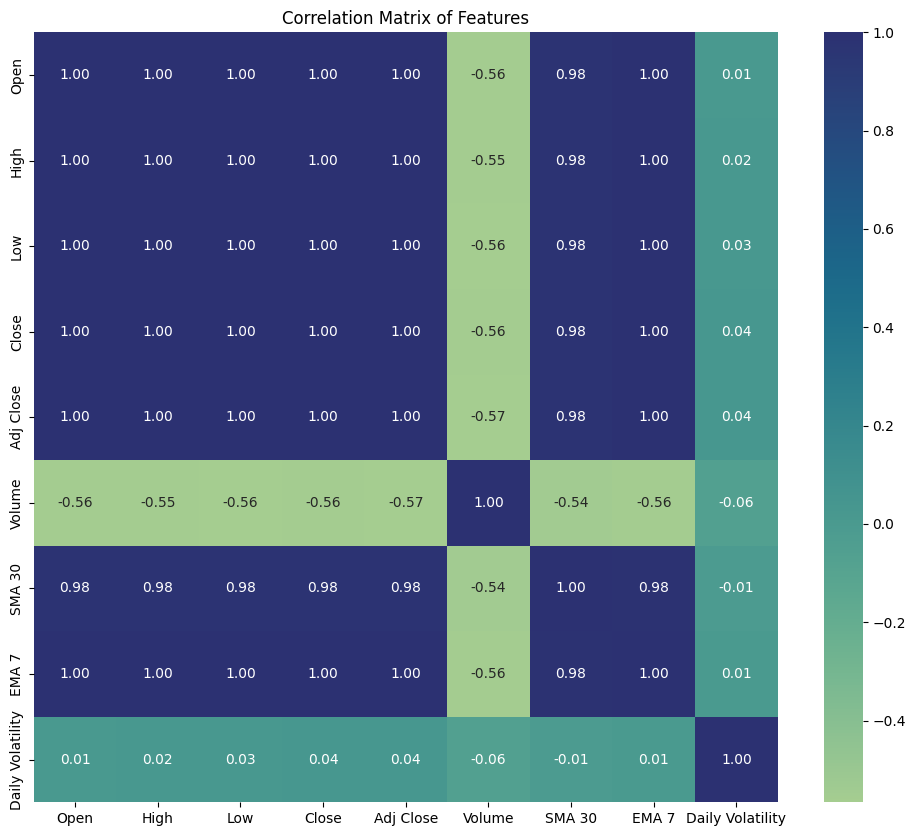

In [11]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='crest', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

### Autocorrelation Analysis
Check for autocorrelation in the 'Close' price using lag plots to determine if there is a relationship between current and past values of the stock price.

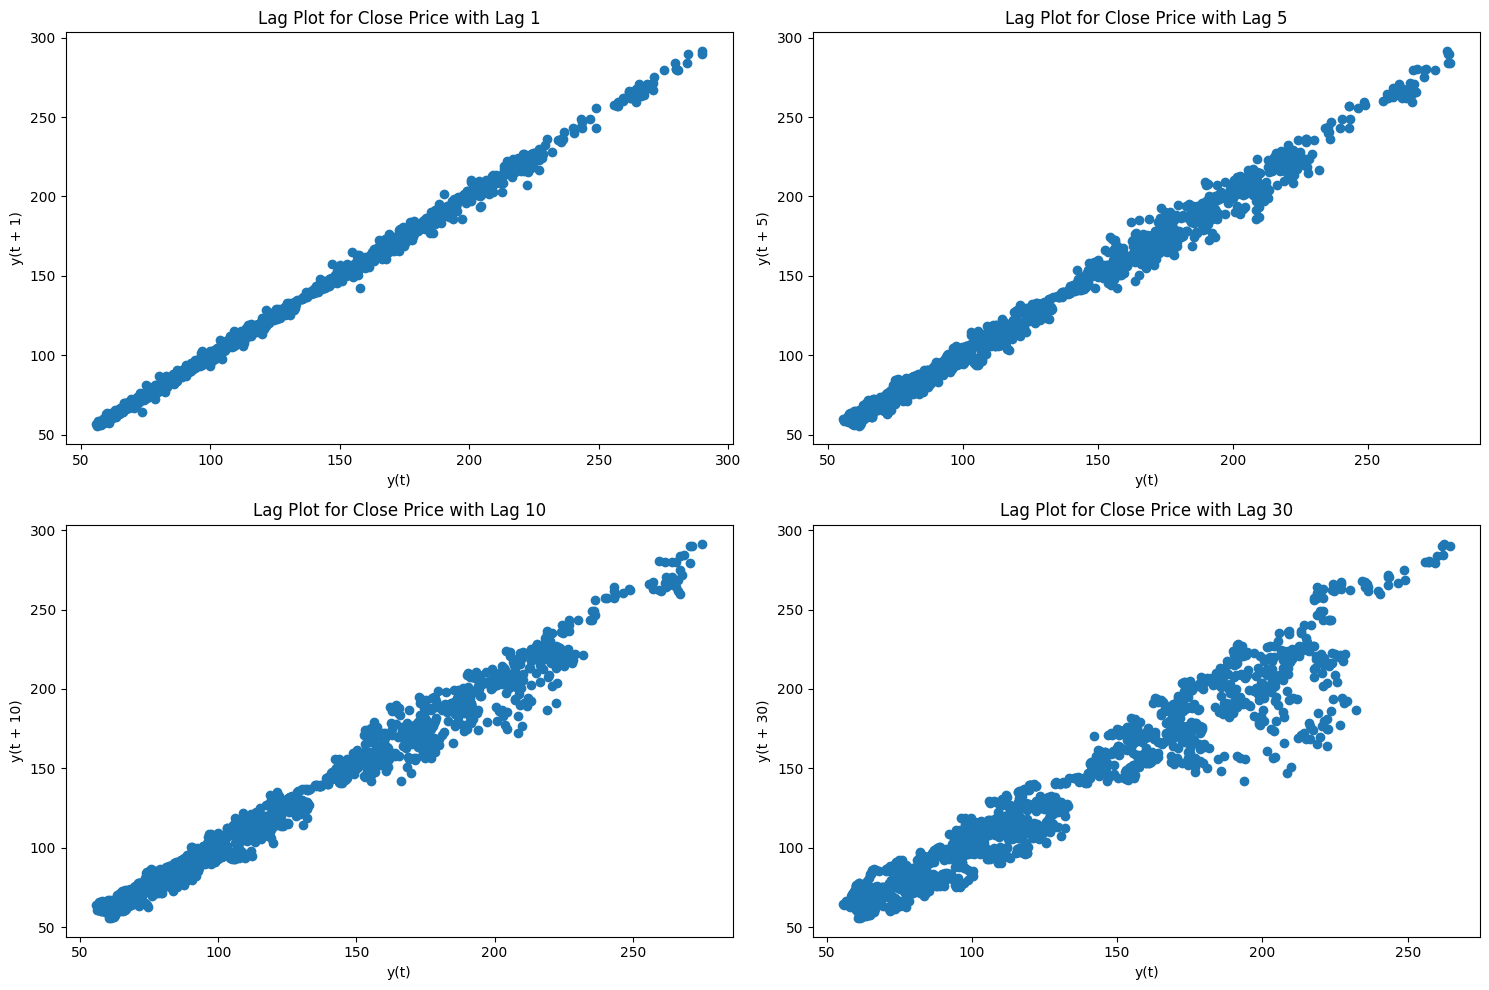

In [12]:
from pandas.plotting import lag_plot

plt.figure(figsize=(15, 10))

lags = [1, 5, 10, 30]

for i, lag in enumerate(lags):
    plt.subplot(2, 2, i + 1)
    lag_plot(df['Close'], lag=lag)
    plt.title(f'Lag Plot for Close Price with Lag {lag}')

plt.tight_layout()
plt.show()

### Distribution Plots

Plot histograms and Kernel Density Estimates (KDEs)to understand their distributions and identify potential skewness or unusual patterns.

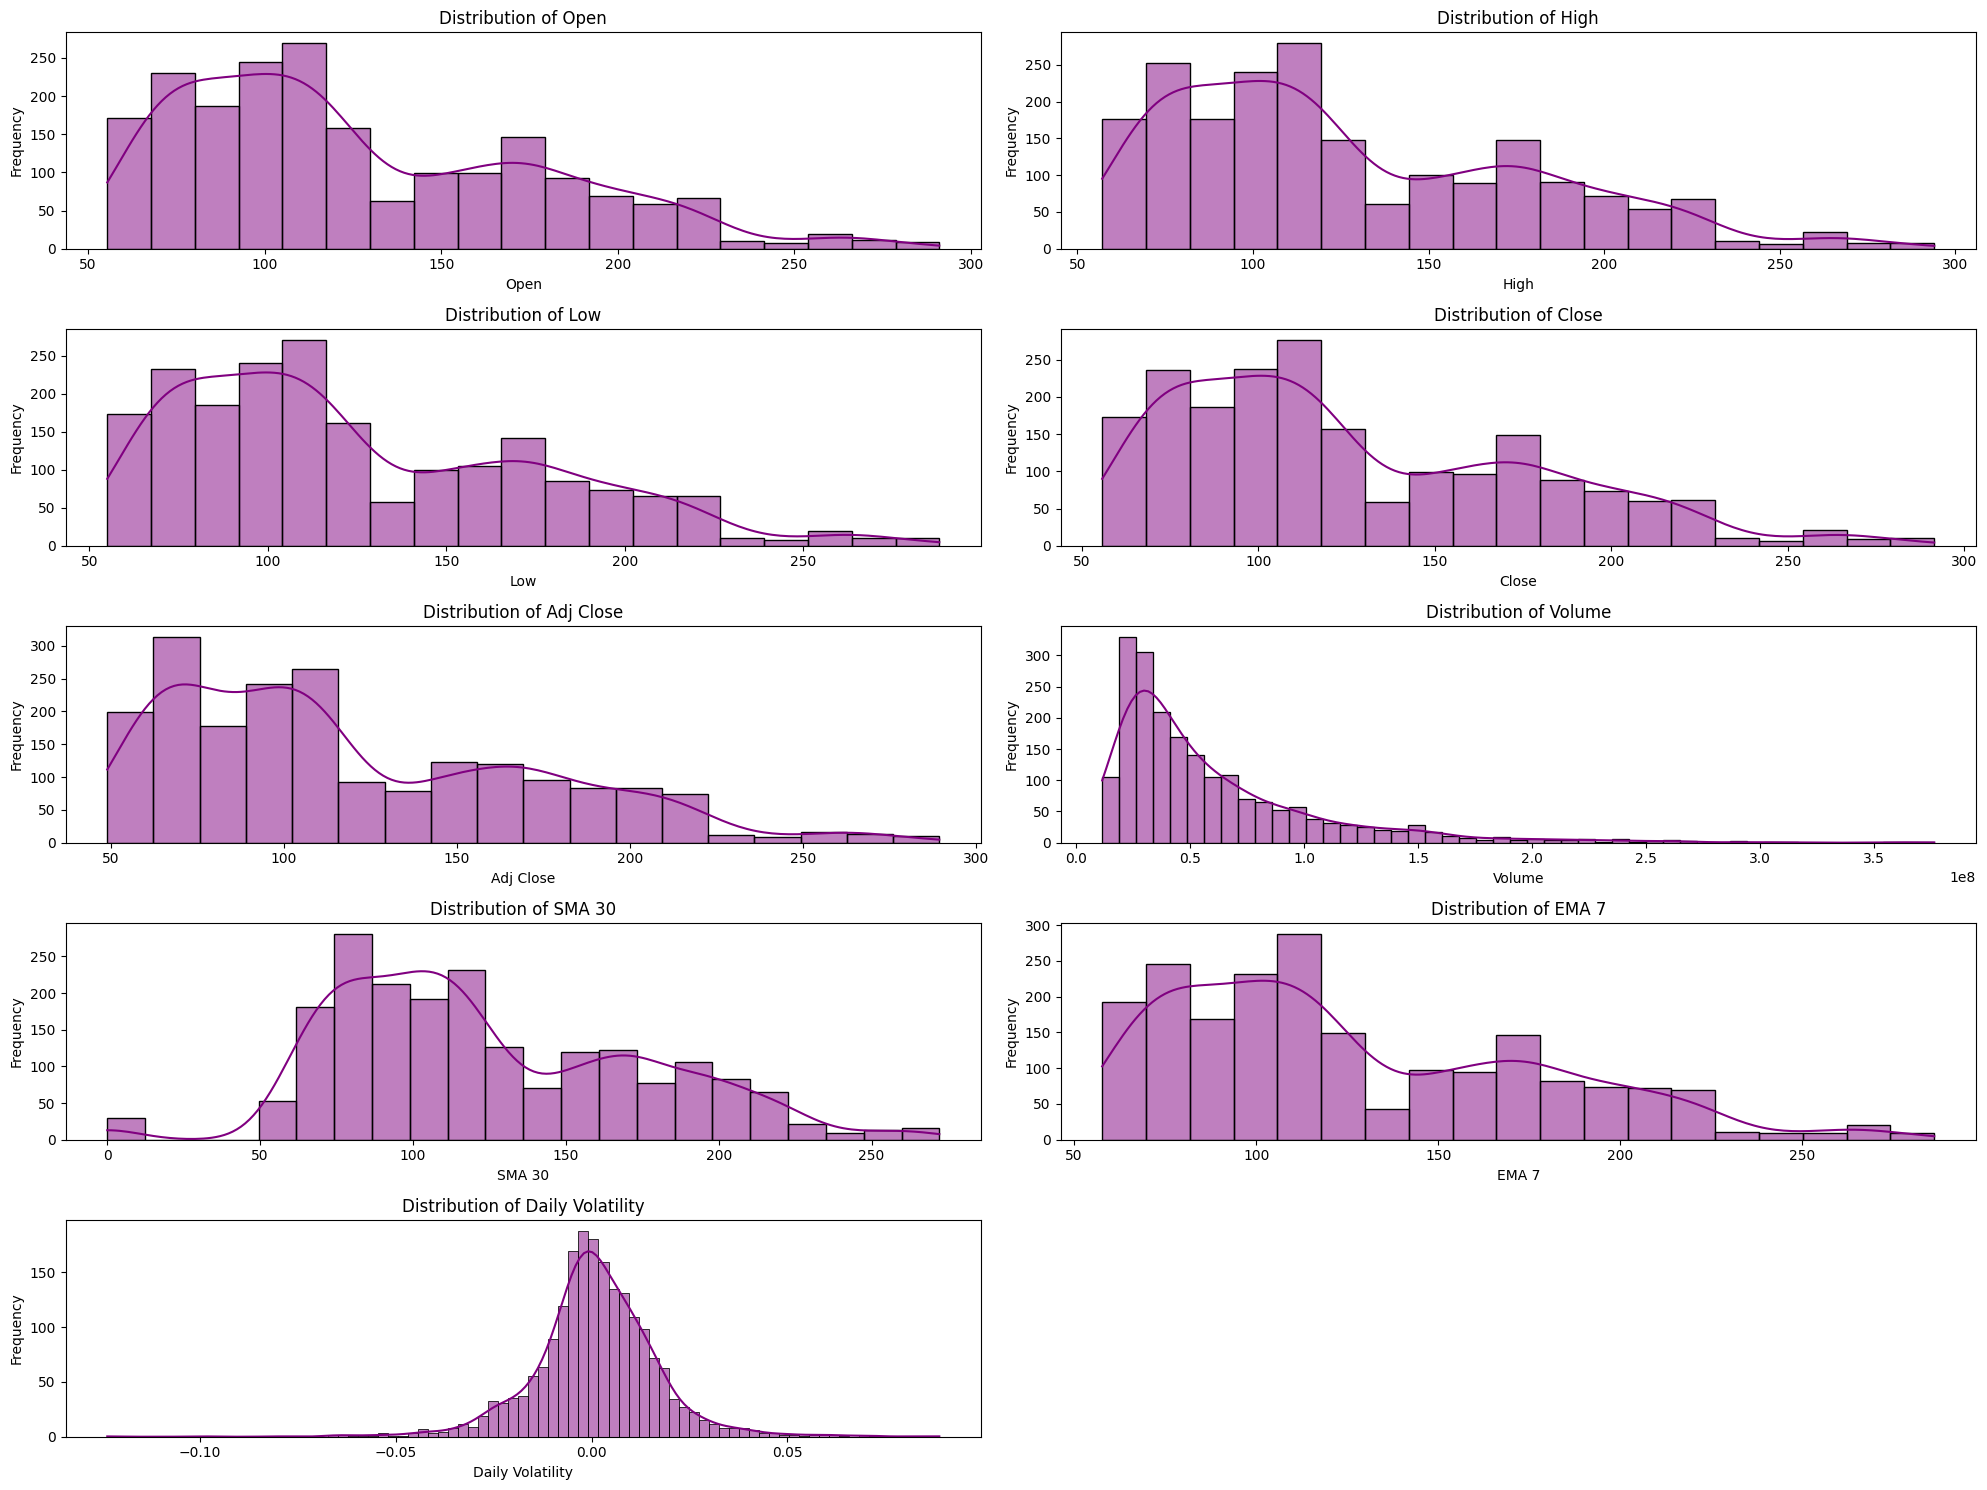

In [13]:
plt.figure(figsize=(20, 15))

features = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'SMA 30', 'EMA 7', 'Daily Volatility']

for i, feature in enumerate(features):
    plt.subplot(5, 2, i + 1)
    sns.histplot(df[feature], kde=True, color='purple')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Box Plots for Outlier Detection




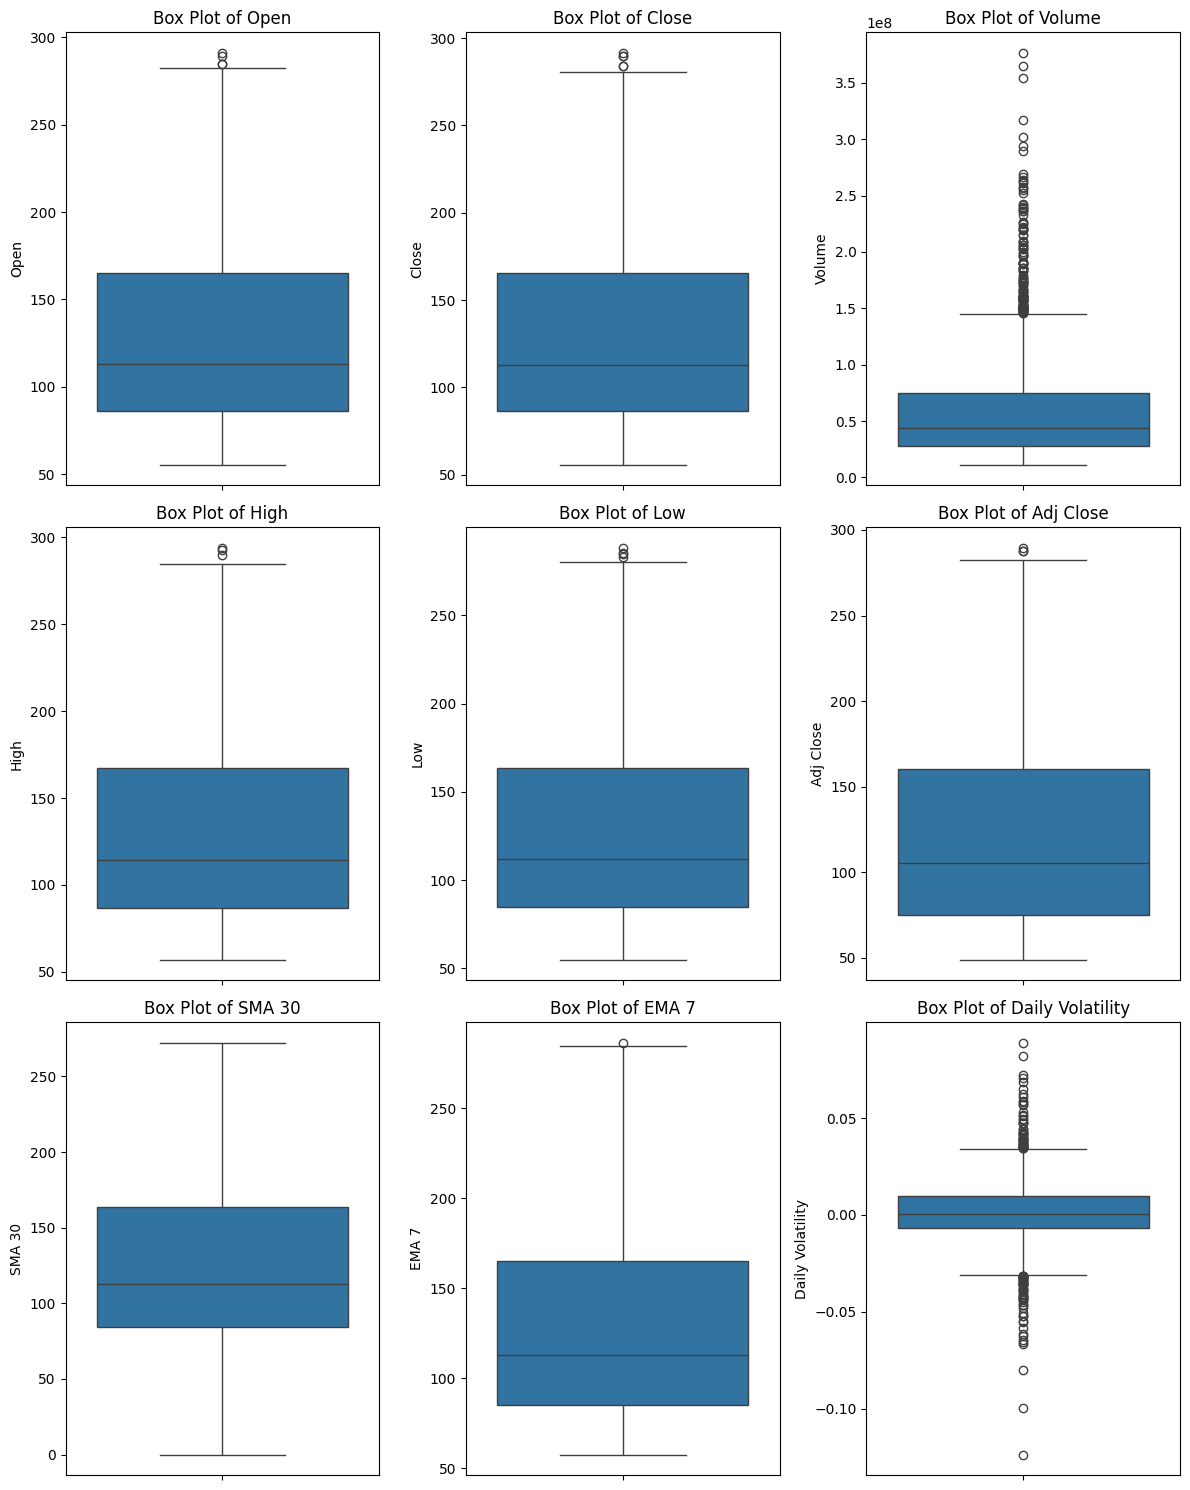

In [14]:
plt.figure(figsize=(12, 15))

features = ['Open', 'Close', 'Volume', 'High', 'Low', 'Adj Close', 'SMA 30', 'EMA 7','Daily Volatility']

for i, feature in enumerate(features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

In [15]:
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Close'] < lower_bound) | (df['Close'] > upper_bound)]

print(f"Number of outliers in 'Close' price: {len(outliers)}")
print("Outliers in 'Close' price:\n", outliers['Close'])

Number of outliers in 'Close' price: 5
Outliers in 'Close' price:
 Date
2019-12-23    284.000000
2019-12-24    284.269989
2019-12-26    289.910004
2019-12-27    289.799988
2019-12-30    291.519989
Name: Close, dtype: float64


Do not remove outliers because it is a stock price forecast

### Prepare Features and Target
Define the features (X) and the target variable (y) from the DataFrame. The 'Close' price is the target variable, and other relevant columns will be features.


In [16]:
X = df.drop('Close', axis=1)
y = df['Close']

In [17]:
split_index = int(len(df) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [18]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1608, 8), (403, 8), (1608,), (403,))

In [19]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'SMA 30',
       'EMA 7', 'Daily Volatility'],
      dtype='object')

### **ARIMA model**

In [20]:
#Import dependencies
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [21]:
ts = df[['Close']]
ts

,Close
Date,
2012-01-03,58.747143
2012-01-04,59.062859
2012-01-05,59.718571
2012-01-06,60.342857
2012-01-09,60.247143
...,...
2019-12-23,284.000000
2019-12-24,284.269989
2019-12-26,289.910004


In [22]:
def adf_test(series):
    result = adfuller(series)
    return {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Values': result[4]
    }

In [23]:
adf_test(ts)

{'ADF Statistic': np.float64(1.2193701254378007),
 'p-value': np.float64(0.9961170178032009),
 'Critical Values': {'1%': np.float64(-3.433622218212895),
  '5%': np.float64(-2.8629854902259004),
  '10%': np.float64(-2.5675395171404802)}}

* Ho:  Data is Non Stationary
* H1:  Data is Stationary

Here value of p > 0.05 means H1 is rejected and Ho is accepted, i.e we fail to reject the null hypothesis. Thus Close price series is not stationary. So to make it stationary differencing is used during modeling.

<Figure size 1200x500 with 0 Axes>

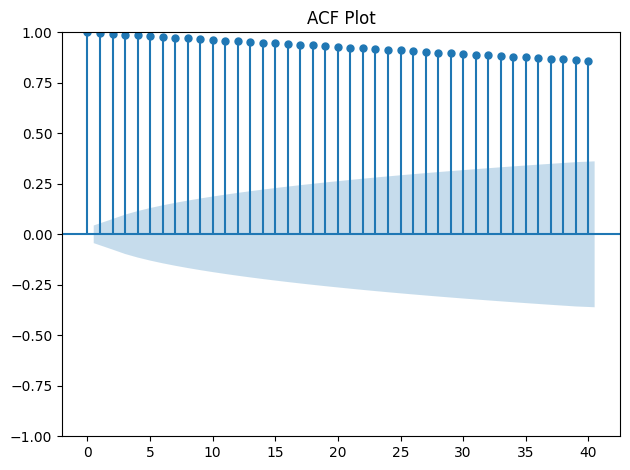

<Figure size 1200x500 with 0 Axes>

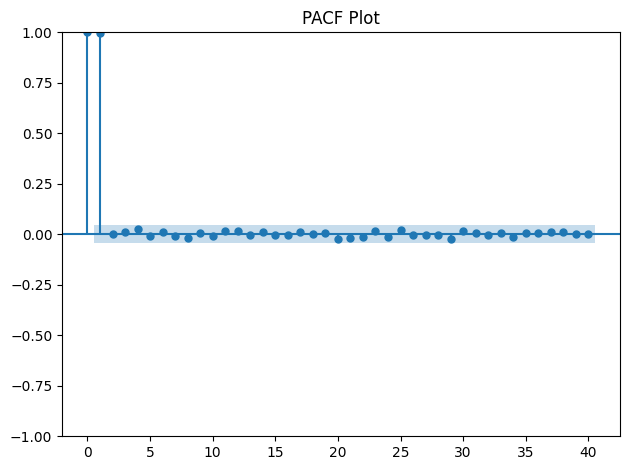

In [24]:
plt.figure(figsize=(12,5))
plot_acf(ts, lags=40)
plt.title("ACF Plot")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(ts, lags=40)
plt.title("PACF Plot")
plt.tight_layout()
plt.show()

The Autocorrelation Function shows a very slow, linear decay. The correlation coefficients start near 1.0 and remain statistically significant (above the blue shaded confidence interval) for all displayed 40 lags.

The Partial Autocorrelation Function shows a massive, significant spike at Lag 1 (close to 1.0), followed by an abrupt cut-off where Lag 2 and subsequent lags are statistically insignificant (hovering near zero).

In [25]:
ts_diff = ts.diff().dropna()
ts_diff

,Close
Date,
2012-01-04,0.315716
2012-01-05,0.655712
2012-01-06,0.624286
2012-01-09,-0.095714
2012-01-10,0.215713
...,...
2019-12-23,4.559998
2019-12-24,0.269989
2019-12-26,5.640015


In [26]:
adf_test(ts_diff)

{'ADF Statistic': np.float64(-13.625534323873282),
 'p-value': np.float64(1.7631231987207507e-25),
 'Critical Values': {'1%': np.float64(-3.433622218212895),
  '5%': np.float64(-2.8629854902259004),
  '10%': np.float64(-2.5675395171404802)}}

* Ho:  Data is Non Stationary
* H1:  Data is Stationary

Here value of p < 0.05 means H1 is Accepted and Ho is rejected. Thus Close price series is stationary.

<Figure size 1200x500 with 0 Axes>

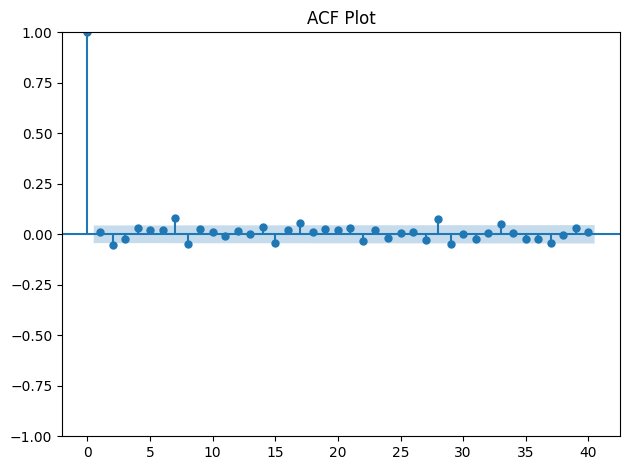

<Figure size 1200x500 with 0 Axes>

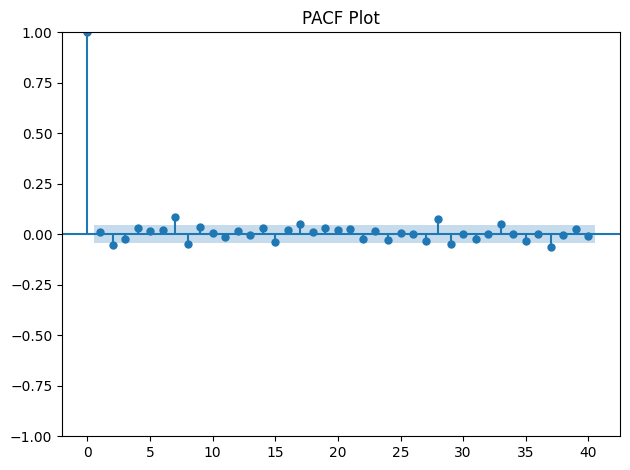

In [27]:
plt.figure(figsize=(12,5))
plot_acf(ts_diff, lags=40)
plt.title("ACF Plot")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(ts_diff, lags=40)
plt.title("PACF Plot")
plt.tight_layout()
plt.show()

In [28]:
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

In [29]:
train.shape, test.shape

((1608, 1), (403, 1))

In [30]:
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\Gururaj G patil\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Gururaj G patil\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Gururaj G patil\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1608
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3083.633
Date:                Fri, 26 Dec 2025   AIC                           6173.265
Time:                        21:12:54   BIC                           6189.412
Sample:                             0   HQIC                          6179.260
                               - 1608                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2829      0.404     -0.701      0.483      -1.074       0.508
ma.L1          0.3284      0.400      0.822      0.411      -0.455       1.111
sigma2         2.7179      0.056     48.115      0.0

In [31]:
fcast_model = model_fit.forecast(steps=len(test))

c:\Users\Gururaj G patil\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Gururaj G patil\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [32]:
aic_arima_111 = model_fit.aic
bic_arima_111 = model_fit.bic

print("AIC: ", aic_arima_111)
print("BIC: ", bic_arima_111)

AIC:  6173.265466776588
BIC:  6189.411839873801


In [33]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [34]:
mae_arima_111 = mean_absolute_error(test, fcast_model)
mse_arima_111 = mean_squared_error(test, fcast_model)
rmse_arima_111 = np.sqrt(mse_arima_111)
mape_arima_111 = mape(test, fcast_model)

print("MAE:", mae_arima_111)
print("RMSE:", rmse_arima_111)
print("MAPE:", mape_arima_111)

MAE: 25.386746296190992
RMSE: 34.034287344996756
MAPE: 11.668391505188037


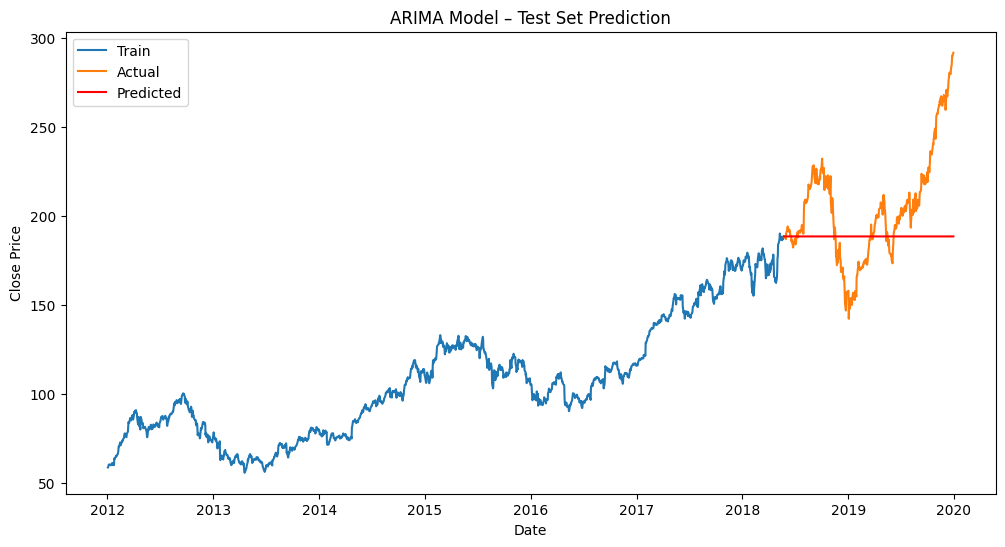

In [35]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, fcast_model, label='Predicted', color='red')

plt.title('ARIMA Model – Test Set Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

`Hyperparameter Tunning`

In [36]:
import itertools

p = range(0, 5)   # AR terms
d = [1]   # Forcing Differencing
q = range(0, 5)   # MA terms

pdq_combinations = list(itertools.product(p, d, q))

In [37]:
import warnings

warnings.filterwarnings("ignore")

results = []

for order in pdq_combinations:
    try:
        model = ARIMA(ts, order=order)
        fit = model.fit()
        results.append({
            'p': order[0],
            'd': order[1],
            'q': order[2],
            'AIC': fit.aic,
            'BIC': fit.bic
        })
    except:
        continue

results_df = pd.DataFrame(results)
results_df.sort_values('AIC').head()

,p,d,q,AIC,BIC
24,4,1,4,8729.336951,8779.789961
17,3,1,2,8733.611712,8767.247052
21,4,1,1,8737.749472,8771.384812
9,1,1,4,8737.847410,8771.482750
18,3,1,3,8738.303269,8777.544499


In [38]:
best_order = tuple(results_df.loc[results_df['AIC'].idxmin()][['p','d','q']])

best_order

(4.0, 1.0, 4.0)

In [39]:
#Trying model with best order(4,1,4)

best_arima = ARIMA(train, order=best_order)
model_fit = best_arima.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1608
Model:                 ARIMA(4, 1, 4)   Log Likelihood               -3076.572
Date:                Fri, 26 Dec 2025   AIC                           6171.144
Time:                        21:13:36   BIC                           6219.583
Sample:                             0   HQIC                          6189.127
                               - 1608                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1465      0.389      0.376      0.707      -0.617       0.910
ar.L2         -0.0495      0.231     -0.214      0.831      -0.503       0.404
ar.L3          0.3162      0.230      1.374      0.1

In [40]:
fcast_best = model_fit.forecast(steps=len(test))
fcast_best.index = test.index
fcast_best

Date
2018-05-24    188.278960
2018-05-25    188.491574
2018-05-29    188.378806
2018-05-30    188.423001
2018-05-31    188.538004
                 ...    
2019-12-23    188.449918
2019-12-24    188.449918
2019-12-26    188.449918
2019-12-27    188.449918
2019-12-30    188.449918
Name: predicted_mean, Length: 403, dtype: float64

In [41]:
aic_arima_414 = model_fit.aic
bic_arima_414 = model_fit.bic

print("AIC: ", aic_arima_414)
print("BIC: ", bic_arima_414)

mae_arima_414 = mean_absolute_error(test, fcast_best)
mse_arima_414 = mean_squared_error(test, fcast_best)
rmse_arima_414 = np.sqrt(mse_arima_414)
mape_arima_414 = mape(test, fcast_best)

print("MAE:", mae_arima_414)
print("RMSE:", rmse_arima_414)
print("MAPE:", mape_arima_414)

AIC:  6171.144128350446
BIC:  6219.583247642084
MAE: 25.370590689914327
RMSE: 34.01692763988185
MAPE: 11.662465339878167


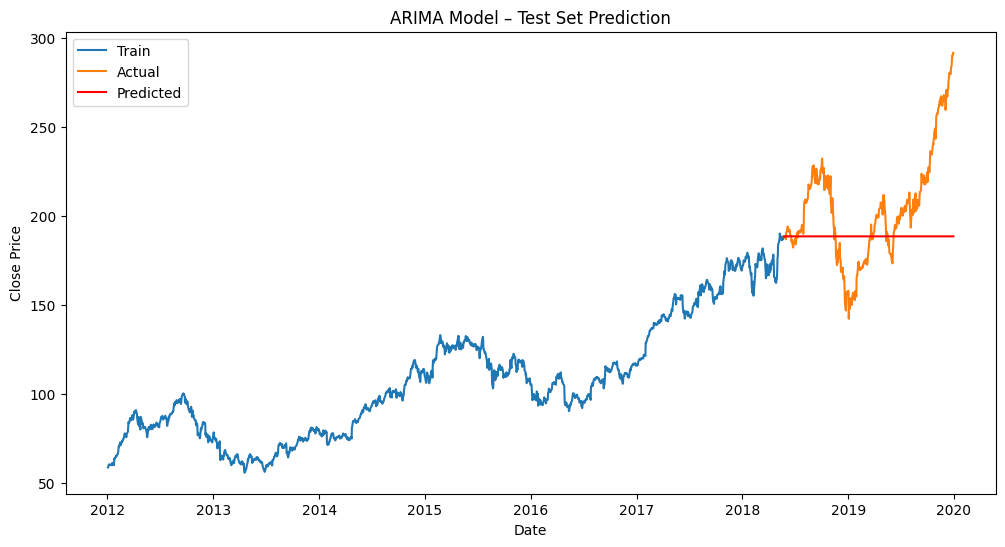

In [42]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, fcast_best, label='Predicted', color='red')

plt.title('ARIMA Model – Test Set Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

### **ARIMAX**

In [43]:
exog = df[['SMA 30', 'EMA 7', 'Volume', 'Daily Volatility']]
exog = exog.iloc[1:]  # align with differencing
exog

,SMA 30,EMA 7,Volume,Daily Volatility
Date,,,,
2012-01-04,0.000000,58.826072,65005500,0.005374
2012-01-05,0.000000,59.049197,67817400,0.011102
2012-01-06,0.000000,59.372612,79573200,0.010454
2012-01-09,0.000000,59.591245,98506100,-0.001586
2012-01-10,0.000000,59.809147,64549100,0.003580
...,...,...,...,...
2019-12-23,268.701334,279.151784,24643000,0.016318
2019-12-24,269.436999,280.431335,12119700,0.000951
2019-12-26,270.368667,282.801002,23280300,0.019840


In [44]:
max = ARIMA(
    ts.iloc[1:],
    exog=exog,
    order=(1,1,1)
)

max_fit = max.fit()

print(max_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2010
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2747.277
Date:                Fri, 26 Dec 2025   AIC                           5508.554
Time:                        21:13:39   BIC                           5547.792
Sample:                             0   HQIC                          5522.958
                               - 2010                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
SMA 30              -0.0551      0.004    -14.013      0.000      -0.063      -0.047
EMA 7                1.6021      0.009    173.142      0.000       1.584       1.620
Volume           -2.224e-09 

In [45]:
fcast_max = max_fit.forecast(steps=len(test), exog=exog.iloc[-len(test):])
fcast_max.index = test.index
fcast_max

Date
2018-05-24    137.909514
2018-05-25    138.542321
2018-05-29    138.243951
2018-05-30    138.203207
2018-05-31    137.761374
                 ...    
2019-12-23    280.796549
2019-12-24    281.986796
2019-12-26    286.748013
2019-12-27    288.360720
2019-12-30    291.448138
Name: predicted_mean, Length: 403, dtype: float64

In [46]:
aic_arimax = max_fit.aic
bic_arimax = max_fit.bic

print("AIC : ", aic_arimax)
print("BIC : ", bic_arimax)

mae_arimax = mean_absolute_error(test, fcast_max)
mse_arimax = mean_squared_error(test, fcast_max)
rmse_arimax = np.sqrt(mse_arimax)
mape_arimax = mape(test, fcast_max)

print("MAE:", mae_arimax)
print("RMSE:", rmse_arimax)
print("MAPE:", mape_arimax)

AIC :  5508.553953259236
BIC :  5547.79169981294
MAE: 41.57931581103896
RMSE: 44.33731671019662
MAPE: 26.804958010027867


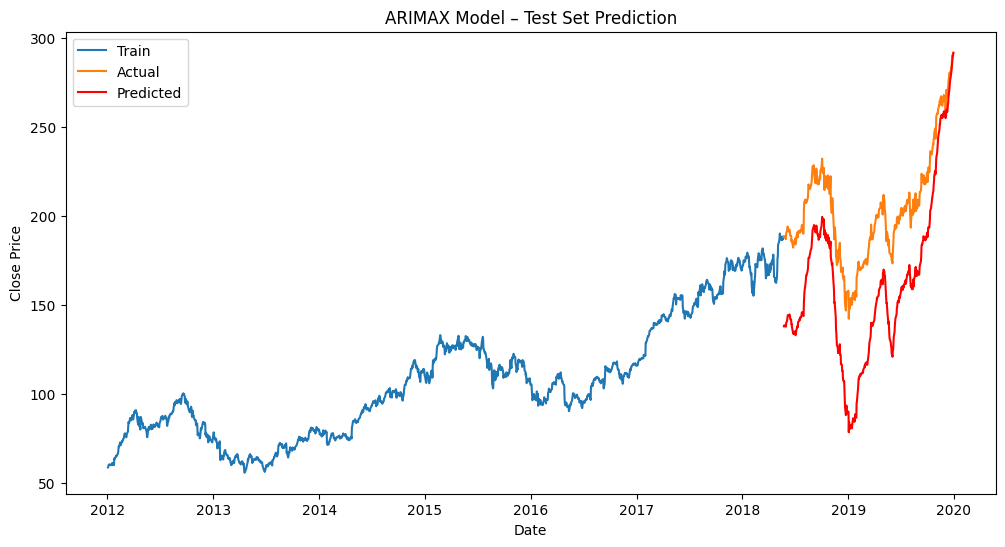

In [47]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, fcast_max, label='Predicted', color='red')

plt.title('ARIMAX Model – Test Set Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [48]:
future_dates = pd.date_range(
    start=df.index[-1],
    periods=31,
    freq='B'
)[1:]
future_dates

DatetimeIndex(['2019-12-31', '2020-01-01', '2020-01-02', '2020-01-03',
               '2020-01-06', '2020-01-07', '2020-01-08', '2020-01-09',
               '2020-01-10', '2020-01-13', '2020-01-14', '2020-01-15',
               '2020-01-16', '2020-01-17', '2020-01-20', '2020-01-21',
               '2020-01-22', '2020-01-23', '2020-01-24', '2020-01-27',
               '2020-01-28', '2020-01-29', '2020-01-30', '2020-01-31',
               '2020-02-03', '2020-02-04', '2020-02-05', '2020-02-06',
               '2020-02-07', '2020-02-10'],
              dtype='datetime64[ns]', freq='B')

In [49]:
future_exog_30 = pd.DataFrame(index=future_dates)

for col in exog.columns:
    model_exog = ExponentialSmoothing(exog[col]).fit()
    future_exog_30[col] = model_exog.forecast(30)

In [50]:
last_exog_values = exog.iloc[-1]

# Fill future_exog_30 by repeating the last known values for each column
for col in exog.columns:
    future_exog_30[col] = last_exog_values[col]

forecast_30 = max_fit.forecast(
    steps=30,
    exog=future_exog_30
)

In [51]:
forecast_30.index = future_dates

In [52]:
forecast_30

2019-12-31    291.437182
2020-01-01    291.449809
2020-01-02    291.447884
2020-01-03    291.448177
2020-01-06    291.448132
2020-01-07    291.448139
2020-01-08    291.448138
2020-01-09    291.448138
2020-01-10    291.448138
2020-01-13    291.448138
2020-01-14    291.448138
2020-01-15    291.448138
2020-01-16    291.448138
2020-01-17    291.448138
2020-01-20    291.448138
2020-01-21    291.448138
2020-01-22    291.448138
2020-01-23    291.448138
2020-01-24    291.448138
2020-01-27    291.448138
2020-01-28    291.448138
2020-01-29    291.448138
2020-01-30    291.448138
2020-01-31    291.448138
2020-02-03    291.448138
2020-02-04    291.448138
2020-02-05    291.448138
2020-02-06    291.448138
2020-02-07    291.448138
2020-02-10    291.448138
Freq: B, Name: predicted_mean, dtype: float64

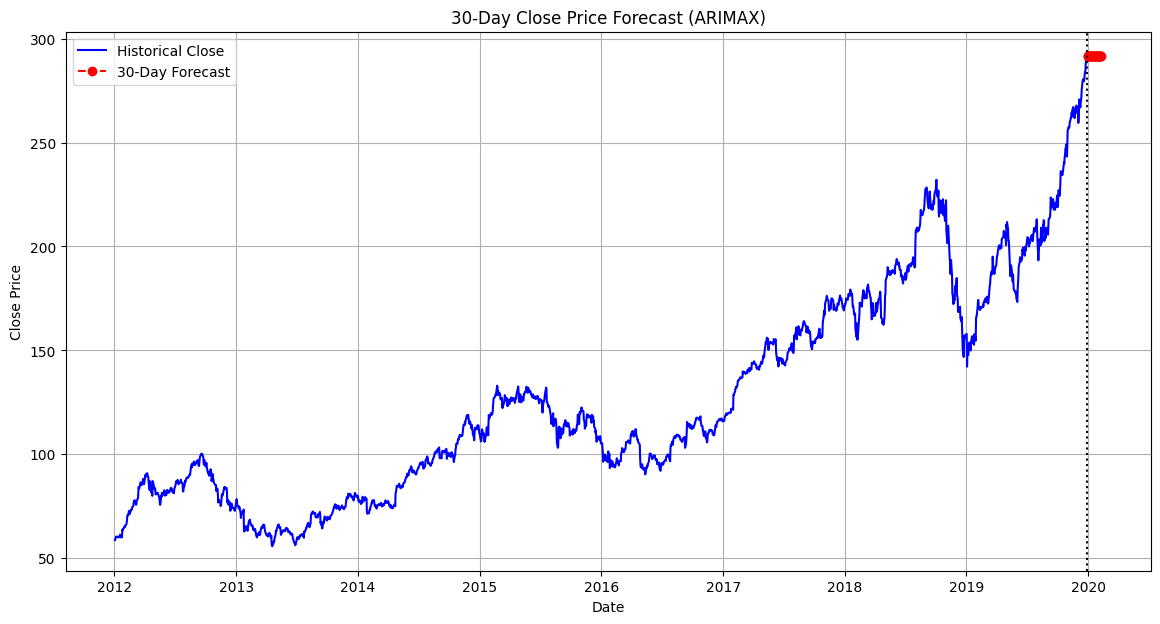

In [53]:
plt.figure(figsize=(14,7))

plt.plot(df['Close'], label='Historical Close', color='blue')

plt.plot(
    forecast_30.index,
    forecast_30,
    label='30-Day Forecast',
    color='red',
    linestyle='--',
    marker='o'
)

plt.axvline(df.index[-1], linestyle=':', color='black')

plt.title('30-Day Close Price Forecast (ARIMAX)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
p = range(0, 5)
d = [1]
q = range(0, 5)

pdq_grid = list(itertools.product(p, d, q))

In [55]:
results = []

for order in pdq_grid:
    try:
        model = ARIMA(
            y_train,
            exog=X_train,
            order=order
        )
        fit = model.fit()

        results.append({
            'p': order[0],
            'd': order[1],
            'q': order[2],
            'AIC': fit.aic,
            'BIC': fit.bic
        })

    except:
        continue

results_df = pd.DataFrame(results)

In [56]:
best_aic = results_df.loc[results_df['AIC'].idxmin()]
best_bic = results_df.loc[results_df['BIC'].idxmin()]

best_aic, best_bic

(p         0.000000
 d         1.000000
 q         4.000000
 AIC   -3458.949888
 BIC   -3388.982271
 Name: 4, dtype: float64,
 p         0.000000
 d         1.000000
 q         1.000000
 AIC   -3458.893705
 BIC   -3405.072462
 Name: 1, dtype: float64)

In [57]:
top_models = results_df.sort_values('AIC').head(5)
top_models

,p,d,q,AIC,BIC
4,0,1,4,-3458.949888,-3388.982271
1,0,1,1,-3458.893705,-3405.072462
20,4,1,0,-3458.403726,-3388.436109
5,1,1,0,-3457.946399,-3404.125156
18,3,1,3,-3457.839969,-3377.108103


In [58]:
def arimax_rmse(order):
    model = ARIMA(
        y_train,
        exog=X_train,
        order=order
    )
    fit = model.fit()

    forecast = fit.forecast(
        steps=len(y_test),
        exog=X_test
    )

    rmse = np.sqrt(mean_squared_error(y_test, forecast))
    return rmse

In [59]:
rmse_results = []

for _, row in top_models.iterrows():
    order = (int(row.p), int(row.d), int(row.q))
    rmse = arimax_rmse(order)

    rmse_results.append({
        'order': order,
        'AIC': row.AIC,
        'RMSE': rmse
    })

rmse_df = pd.DataFrame(rmse_results)
rmse_df

,order,AIC,RMSE
0,"(0, 1, 4)",-3458.949888,4.530648
1,"(0, 1, 1)",-3458.893705,4.534154
2,"(4, 1, 0)",-3458.403726,4.530885
3,"(1, 1, 0)",-3457.946399,4.534318
4,"(3, 1, 3)",-3457.839969,4.518712


In [60]:
best_order = rmse_df.sort_values('RMSE').iloc[0]['order']
best_order

(3, 1, 3)

In [61]:
final_model = ARIMA(
    y_train,
    exog=X_train,
    order=best_order
)

final_fit = final_model.fit()
print(final_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1608
Model:                 ARIMA(3, 1, 3)   Log Likelihood                1743.920
Date:                Fri, 26 Dec 2025   AIC                          -3457.840
Time:                        21:14:52   BIC                          -3377.108
Sample:                             0   HQIC                         -3427.868
                               - 1608                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Open                -0.0034      0.001     -4.167      0.000      -0.005      -0.002
High                 0.0185      0.000     80.106      0.000       0.018       0.019
Low                  0.0097 

In [62]:
best_max_fcast = final_fit.forecast(
    steps=len(y_test),
    exog=X_test
)
best_max_fcast

1608    188.135462
1609    188.601586
1610    187.890631
1611    187.477423
1612    186.827870
           ...    
2006    295.633429
2007    295.940159
2008    301.932697
2009    301.910397
2010    303.693938
Name: predicted_mean, Length: 403, dtype: float64

In [63]:
print("AIC : ",final_fit.aic)
print("BIC : ",final_fit.bic)

mae_best_arimax = mean_absolute_error(y_test, best_max_fcast)
mse_best_arimax = mean_squared_error(y_test, best_max_fcast)
rmse_best_arimax = np.sqrt(mse_best_arimax)
mape_best_arimax = mape(y_test, best_max_fcast)

print("MAE:", mae_best_arimax)
print("RMSE:", rmse_best_arimax)
print("MAPE:", mape_best_arimax)

AIC :  -3457.839968856144
BIC :  -3377.108103370081
MAE: 3.356131947926542
RMSE: 4.518712310681005
MAPE: 1.5009980255151154


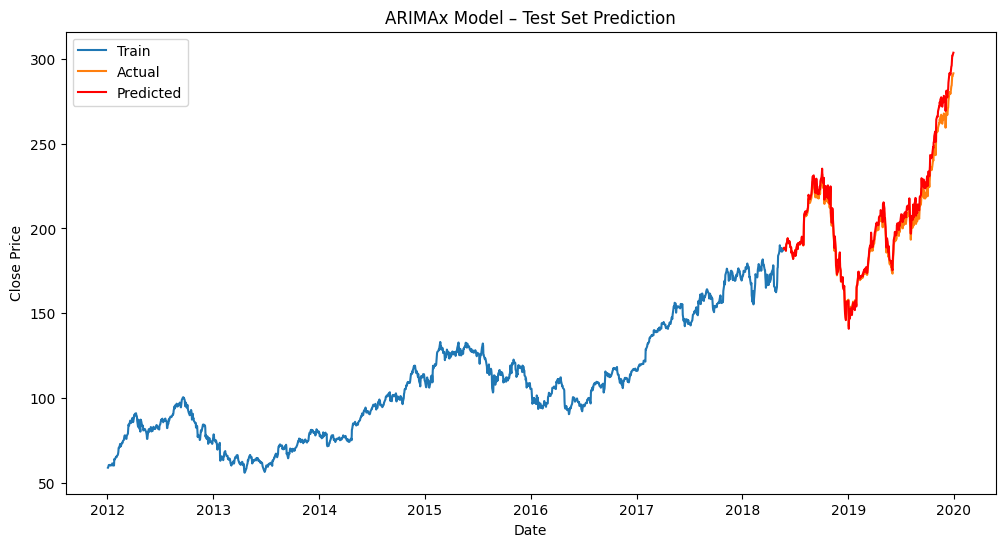

In [64]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, best_max_fcast, label='Predicted', color='red')

plt.title('ARIMAx Model – Test Set Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [65]:
future_exog_30 = pd.DataFrame(index=future_dates)

for col in exog.columns:
    model_exog = ExponentialSmoothing(exog[col]).fit()
    future_exog_30[col] = model_exog.forecast(30)

In [66]:
future_dates = pd.date_range(
    start=df.index[-1],
    periods=31,
    freq='B'
)[1:]
future_dates
# Get the full set of exogenous features that final_model was trained on
full_exog_features = df.drop('Close', axis=1)

# Create a DataFrame for future exogenous variables with the correct columns
future_exog_30 = pd.DataFrame(index=future_dates, columns=full_exog_features.columns)

# Get the last known values for all exogenous variables
last_full_exog_values = full_exog_features.iloc[-1]

# Fill future_exog_30 by repeating the last known values for each column
for col in future_exog_30.columns:
    future_exog_30[col] = last_full_exog_values[col]

forecast_30 = final_fit.forecast(
    steps=30,
    exog=future_exog_30
)

In [67]:
forecast_30.index = future_dates

In [68]:
forecast_30

2019-12-31    303.712625
2020-01-01    303.699031
2020-01-02    303.703989
2020-01-03    303.703172
2020-01-06    303.695774
2020-01-07    303.697895
2020-01-08    303.698524
2020-01-09    303.694634
2020-01-10    303.695378
2020-01-13    303.696212
2020-01-14    303.694241
2020-01-15    303.694390
2020-01-16    303.695055
2020-01-17    303.694099
2020-01-20    303.694035
2020-01-21    303.694478
2020-01-22    303.694038
2020-01-23    303.693926
2020-01-24    303.694193
2020-01-27    303.694004
2020-01-28    303.693905
2020-01-29    303.694054
2020-01-30    303.693982
2020-01-31    303.693910
2020-02-03    303.693989
2020-02-04    303.693966
2020-02-05    303.693920
2020-02-06    303.693959
2020-02-07    303.693956
2020-02-10    303.693928
Freq: B, Name: predicted_mean, dtype: float64

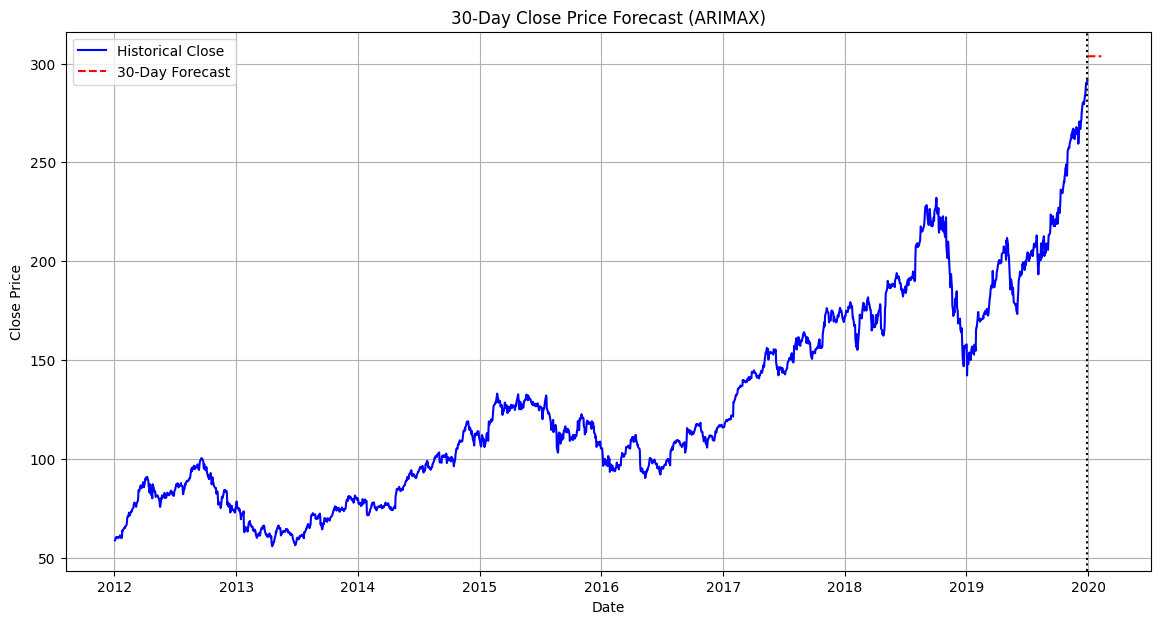

In [69]:
plt.figure(figsize=(14,7))

# Historical data
plt.plot(df['Close'], label='Historical Close', color='blue')

# 30-day forecast as LINE (no dots)
plt.plot(
    forecast_30.index,
    forecast_30,
    label='30-Day Forecast',
    color='red',
    linestyle='--'   # keep dashed line if you like
)

# Vertical split line
plt.axvline(df.index[-1], linestyle=':', color='black')

plt.title('30-Day Close Price Forecast (ARIMAX)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

### **SARIMA**

For stock prices, common seasonal periods:

Pattern	Period
* Weekly	s = 5
* Monthly	s = 21
* Quarterly	s = 63

In [70]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

order = (2, 1, 2)
seasonal_order = (1, 1, 1, 5)   # Weekly seasonality


sarima1 = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima1_fit = sarima1.fit()
print(sarima1_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               Close   No. Observations:                 1608
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 5)   Log Likelihood               -3074.631
Date:                             Fri, 26 Dec 2025   AIC                           6163.262
Time:                                     21:15:02   BIC                           6200.880
Sample:                                          0   HQIC                          6177.234
                                            - 1608                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1033      0.599     -1.842      0.065      -2.277       0.071
ar.L2         -0.1596      

In [71]:
fcast_sarima1 = sarima1_fit.forecast(
    steps=len(y_test)
)
fcast_sarima1.index = test.index
fcast_sarima1

Date
2018-05-24    188.527108
2018-05-25    188.583315
2018-05-29    188.628828
2018-05-30    188.752381
2018-05-31    188.792076
                 ...    
2019-12-23    220.658339
2019-12-24    220.713532
2019-12-26    220.846923
2019-12-27    220.893260
2019-12-30    220.955078
Name: predicted_mean, Length: 403, dtype: float64

In [72]:
print("AIC : ",sarima1_fit.aic)
print("BIC : ",sarima1_fit.bic)

mae_sarima = mean_absolute_error(test, fcast_sarima1)
mse_sarima = mean_squared_error(test, fcast_sarima1)
rmse_sarima = np.sqrt(mse_sarima)
mape_sarima = mape(y_test, fcast_sarima1)

print("MAE:", mae_sarima)
print("RMSE:", rmse_sarima)
print("MAPE:", mape_sarima)

AIC :  6163.262099922347
BIC :  6200.880112937798
MAE: 20.765956722953803
RMSE: 26.366846568054587
MAPE: 10.328363258726577


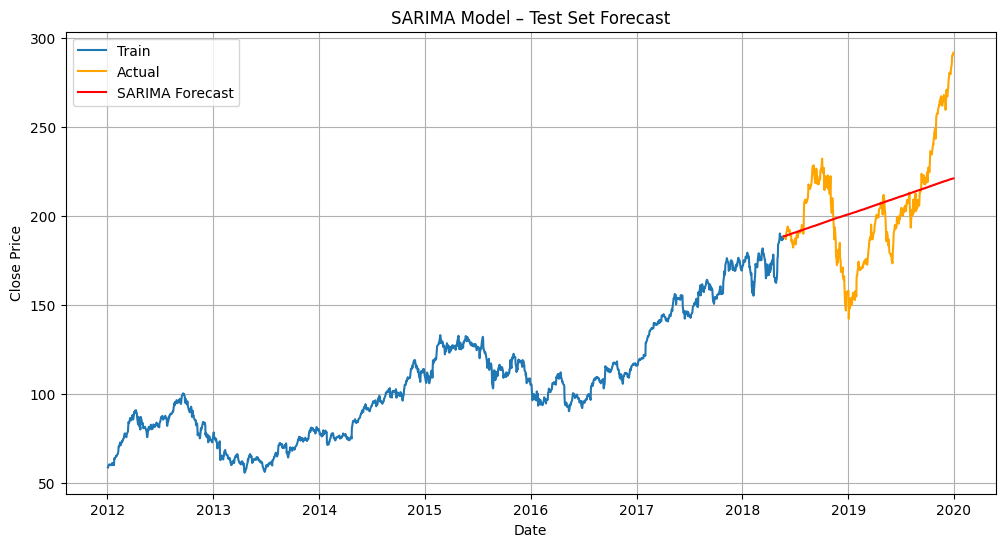

In [73]:
plt.figure(figsize=(12,6))

plt.plot(train, label='Train')
plt.plot(test, label='Actual', color='orange')
plt.plot(test.index, fcast_sarima1, label='SARIMA Forecast', color='red')

plt.title('SARIMA Model – Test Set Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

`Hyperparameter Tunning`

In [74]:
p = q = range(1, 4)     # 1,2,3
P = Q = range(0, 3)     # 0,1,2
d = [1]
D = [0]
s = 5                  # weekly seasonality

In [75]:
pdq = list(itertools.product(p, d, q))
seasonal_pdq = list(itertools.product(P, D, Q, [s]))

len(pdq), len(seasonal_pdq)

(9, 9)

In [76]:
results = []

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fit = model.fit()

            results.append({
                'order': order,
                'seasonal_order': seasonal_order,
                'AIC': fit.aic,
                'BIC': fit.bic
            })

        except Exception as e:
            continue

results_df = pd.DataFrame(results)

In [77]:
results_df.sort_values('AIC').head(10)

,order,seasonal_order,AIC,BIC
50,"(2, 1, 3)","(1, 0, 2, 5)",6128.469199,6176.829568
47,"(2, 1, 3)","(0, 0, 2, 5)",6128.695323,6171.682318
53,"(2, 1, 3)","(2, 0, 2, 5)",6129.514153,6183.247896
41,"(2, 1, 2)","(1, 0, 2, 5)",6129.882417,6172.874432
44,"(2, 1, 2)","(2, 0, 2, 5)",6130.842757,6179.208773
74,"(3, 1, 3)","(0, 0, 2, 5)",6130.977345,6179.337713
38,"(2, 1, 2)","(0, 0, 2, 5)",6131.153194,6168.771207
77,"(3, 1, 3)","(1, 0, 2, 5)",6131.281034,6185.014777
80,"(3, 1, 3)","(2, 0, 2, 5)",6133.237299,6192.344417
43,"(2, 1, 2)","(2, 0, 1, 5)",6134.022039,6177.019071


In [78]:
def sarima_rmse(order, seasonal_order):
    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fit = model.fit()

    forecast = fit.get_forecast(steps=len(test)).predicted_mean
    rmse = np.sqrt(mean_squared_error(test, forecast))
    return rmse

In [79]:
top_models = results_df.sort_values('AIC').head(5)

rmse_results = []

for _, row in top_models.iterrows():
    rmse = sarima_rmse(row['order'], row['seasonal_order'])

    rmse_results.append({
        'order': row['order'],
        'seasonal_order': row['seasonal_order'],
        'AIC': row['AIC'],
        'RMSE': rmse
    })

rmse_df = pd.DataFrame(rmse_results)
rmse_df

,order,seasonal_order,AIC,RMSE
0,"(2, 1, 3)","(1, 0, 2, 5)",6128.469199,33.976777
1,"(2, 1, 3)","(0, 0, 2, 5)",6128.695323,34.056102
2,"(2, 1, 3)","(2, 0, 2, 5)",6129.514153,33.887984
3,"(2, 1, 2)","(1, 0, 2, 5)",6129.882417,33.964412
4,"(2, 1, 2)","(2, 0, 2, 5)",6130.842757,33.934299


In [80]:
best_model = rmse_df.sort_values('RMSE').iloc[0]
best_model

order                (2, 1, 3)
seasonal_order    (2, 0, 2, 5)
AIC                6129.514153
RMSE                 33.887984
Name: 2, dtype: object

In [81]:
final_sarima = SARIMAX(
    ts,
    order=best_model['order'],
    seasonal_order=best_model['seasonal_order'],
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_sarima.fit()
print(final_fit.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                  Close   No. Observations:                 2011
Model:             SARIMAX(2, 1, 3)x(2, 0, [1, 2], 5)   Log Likelihood               -4339.628
Date:                                Fri, 26 Dec 2025   AIC                           8699.255
Time:                                        21:20:26   BIC                           8755.244
Sample:                                             0   HQIC                          8719.816
                                               - 2011                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3923      0.096     14.431      0.000       1.203       1.581
ar.

In [82]:
fcast_sarimax1 = final_fit.get_forecast(steps=len(test)).predicted_mean
fcast_sarimax1.index = test.index
fcast_sarimax1

Date
2018-05-24    291.559973
2018-05-25    291.588845
2018-05-29    291.711776
2018-05-30    292.062227
2018-05-31    292.279837
                 ...    
2019-12-23    292.454648
2019-12-24    292.454648
2019-12-26    292.454648
2019-12-27    292.454648
2019-12-30    292.454648
Name: predicted_mean, Length: 403, dtype: float64

In [83]:
print("AIC : ",final_fit.aic)
print("BIC : ",final_fit.bic)

mae_sarimax = mean_absolute_error(test, fcast_sarimax1)
mse_sarimax = mean_squared_error(test, fcast_sarimax1)
rmse_sarimax = np.sqrt(mse_sarimax)
mape_sarimax = mape(test, fcast_sarimax1)

print("MAE:", mae_sarimax)
print("RMSE:", rmse_sarimax)
print("MAPE:", mape_sarimax)

AIC :  8699.255449110344
BIC :  8755.244453679057
MAE: 87.91308824833634
RMSE: 92.88124089702693
MAPE: 45.959342246693566


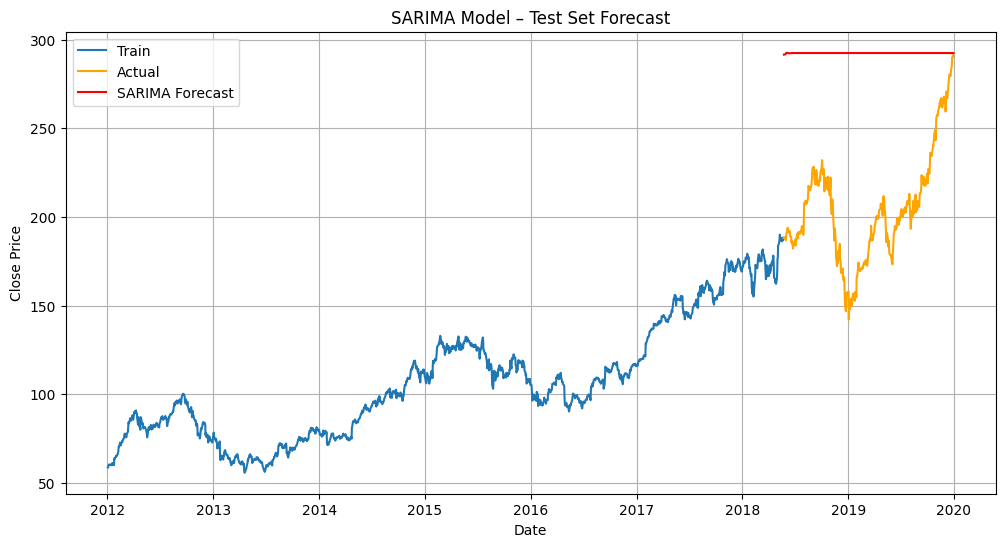

In [84]:
plt.figure(figsize=(12,6))

plt.plot(train, label='Train')
plt.plot(test, label='Actual', color='orange')
plt.plot(test.index, fcast_sarimax1, label='SARIMA Forecast', color='red')

plt.title('SARIMA Model – Test Set Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

### **LSTM**

In [85]:
#Use a DEDICATED scaler ONLY for Close
close_scaler = MinMaxScaler(feature_range=(0,1))
scaled_close = close_scaler.fit_transform(df[['Close']])

In [86]:
#Create sequences from scaled Close only
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_close, window_size=60)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [87]:
X

array([[[0.01254462],
        [0.01388393],
        [0.01666555],
        ...,
        [0.13117306],
        [0.13571824],
        [0.13762114]],

       [[0.01388393],
        [0.01666555],
        [0.01931386],
        ...,
        [0.13571824],
        [0.13762114],
        [0.13291841]],

       [[0.01666555],
        [0.01931386],
        [0.01890783],
        ...,
        [0.13762114],
        [0.13291841],
        [0.12667035]],

       ...,

       [[0.71607349],
        [0.69219028],
        [0.70008066],
        ...,
        [0.94875498],
        [0.96809914],
        [0.96924447]],

       [[0.69219028],
        [0.70008066],
        [0.72633947],
        ...,
        [0.96809914],
        [0.96924447],
        [0.99317022]],

       [[0.70008066],
        [0.72633947],
        [0.72655159],
        ...,
        [0.96924447],
        [0.99317022],
        [0.99270351]]], shape=(1951, 60, 1))

In [88]:
split = int(len(X) * 0.8)
xtrain, xtest = X[:split], X[split:]
ytrain, ytest = y[:split], y[split:]

In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

%pip install keras-tuner
import keras_tuner as kt

lnn1 = Sequential()

lnn1.add(LSTM(50, return_sequences=True, input_shape=(xtrain.shape[1], 1)))
lnn1.add(Dropout(0.2))

lnn1.add(LSTM(50))
lnn1.add(Dropout(0.2))

lnn1.add(Dense(1))  # output layer

lnn1.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

lnn1.summary()


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
history = lnn1.fit(
    xtrain, ytrain,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 43s 196ms/step - loss: 0.0055 - val_loss: 0.0012
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - loss: 8.1158e-04 - val_loss: 9.7568e-04
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 6.9808e-04 - val_loss: 0.0011
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 6.1447e-04 - val_loss: 0.0011
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 5.7560e-04 - val_loss: 0.0012
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - loss: 6.4240e-04 - val_loss: 9.8453e-04
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - loss: 6.0261e-04 - val_loss: 8.8694e-04
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 5.6417e-04 - val_loss: 6.5618e-04
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 5.1150e-04 - val_loss: 6.5591e-04
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 5.0653e-04 - val_loss: 7.9157e-04
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - loss: 5.1891

In [91]:
ypred_test = lnn1.predict(xtest)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step


In [92]:
y_pred_inv = close_scaler.inverse_transform(ypred_test)
y_test_inv = close_scaler.inverse_transform(ytest.reshape(-1,1))

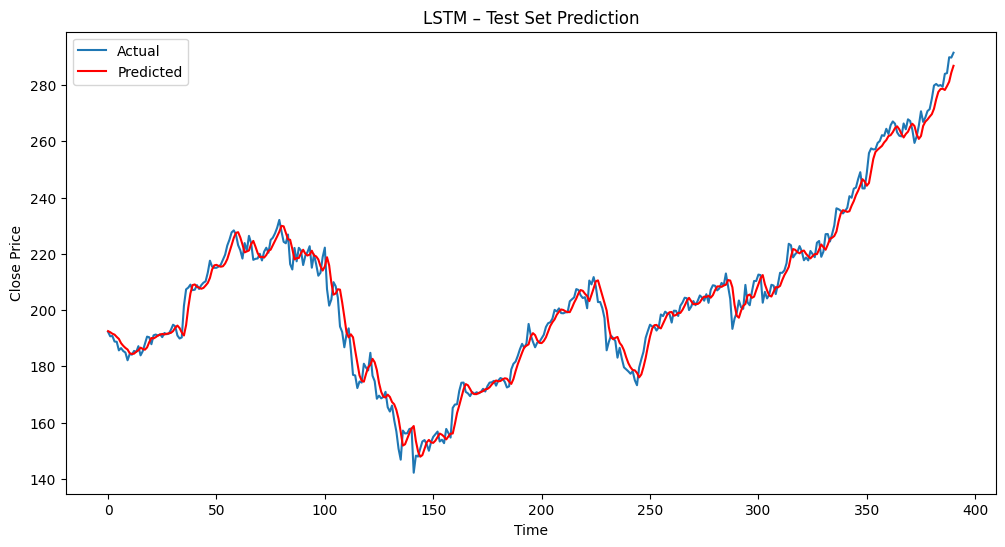

In [93]:
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted', color='red')
plt.title('LSTM – Test Set Prediction')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [94]:
last_60_days = scaled_close[-60:]
current_input = last_60_days.reshape((1, 60, 1))

future_predictions = []

for _ in range(30):
    next_pred = lnn1.predict(current_input, verbose=0)[0,0]
    future_predictions.append(next_pred)

    current_input = np.append(
        current_input[:, 1:, :],
        [[[next_pred]]],
        axis=1
    )

In [95]:
future_predictions = np.array(future_predictions).reshape(-1,1)
future_predictions_inv = close_scaler.inverse_transform(future_predictions)

In [96]:
future_predictions_inv

array([[288.65143],
       [288.3076 ],
       [287.27603],
       [286.0594 ],
       [284.88092],
       [283.82138],
       [282.8923 ],
       [282.07526],
       [281.34283],
       [280.6688 ],
       [280.03238],
       [279.41916],
       [278.82028],
       [278.231  ],
       [277.6493 ],
       [277.0748 ],
       [276.50793],
       [275.94937],
       [275.39966],
       [274.8593 ],
       [274.3285 ],
       [273.8072 ],
       [273.29544],
       [272.7931 ],
       [272.29984],
       [271.8154 ],
       [271.33957],
       [270.87213],
       [270.4127 ],
       [269.96127]], dtype=float32)

In [97]:
future_dates = pd.date_range(
    start=df.index[-1],
    periods=31,
    freq='B'
)[1:]

In [98]:
future_dates

DatetimeIndex(['2019-12-31', '2020-01-01', '2020-01-02', '2020-01-03',
               '2020-01-06', '2020-01-07', '2020-01-08', '2020-01-09',
               '2020-01-10', '2020-01-13', '2020-01-14', '2020-01-15',
               '2020-01-16', '2020-01-17', '2020-01-20', '2020-01-21',
               '2020-01-22', '2020-01-23', '2020-01-24', '2020-01-27',
               '2020-01-28', '2020-01-29', '2020-01-30', '2020-01-31',
               '2020-02-03', '2020-02-04', '2020-02-05', '2020-02-06',
               '2020-02-07', '2020-02-10'],
              dtype='datetime64[ns]', freq='B')

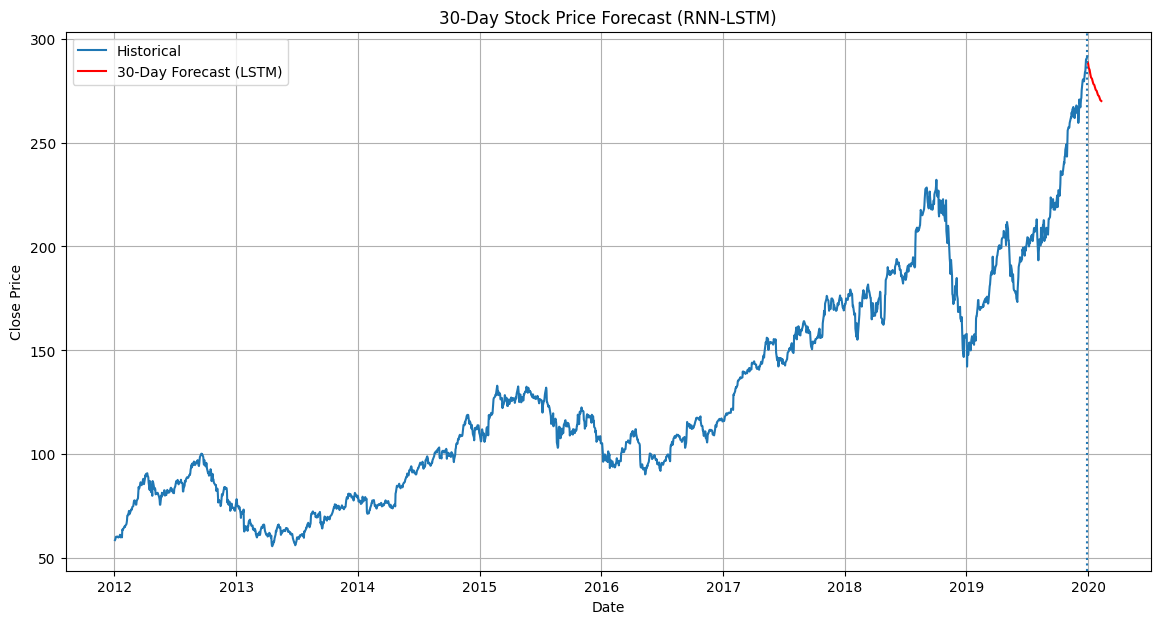

In [99]:
plt.figure(figsize=(14,7))
plt.plot(df['Close'], label='Historical')
plt.plot(future_dates, future_predictions_inv,
         label='30-Day Forecast (LSTM)', color='red')
plt.axvline(df.index[-1], linestyle=':')
plt.title('30-Day Stock Price Forecast (RNN-LSTM)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [100]:
mae_lstm = mean_absolute_error(y_test_inv, y_pred_inv)
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape_lstm = mape(y_test_inv, y_pred_inv)

print("MAE:", mae_lstm)
print("RMSE:", rmse_lstm)
print("MAPE:", mape_lstm)

MAE: 3.1961879196696166
RMSE: 4.2204031751781415
MAPE: 1.5950098088323612


In [101]:
def build_lstm_model(hp):
    model = Sequential()

    # First LSTM layer
    model.add(
        LSTM(
            units=hp.Int('units_1', 32, 128, step=32),
            return_sequences=True,
            input_shape=(xtrain.shape[1], 1)
        )
    )
    model.add(Dropout(hp.Float('dropout_1', 0.1, 0.5, step=0.1)))

    # Second LSTM layer
    model.add(
        LSTM(
            units=hp.Int('units_2', 32, 128, step=32)
        )
    )
    model.add(Dropout(hp.Float('dropout_2', 0.1, 0.5, step=0.1)))

    # Output layer
    model.add(Dense(1))

    # Optimizer tuning
    model.compile(
        optimizer=Adam(
            learning_rate=hp.Float(
                'learning_rate', 1e-4, 1e-2, sampling='log'
            )
        ),
        loss='mean_squared_error'
    )

    return model

In [102]:
tuner = kt.RandomSearch(
    build_lstm_model,
    objective='val_loss',
    max_trials=15,          # increase for better results
    executions_per_trial=1,
    directory='lstm_tuning',
    project_name='stock_price_lstm'
)

Reloading Tuner from lstm_tuning\stock_price_lstm\tuner0.json


In [103]:
tuner.search(
    xtrain, ytrain,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

In [104]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters(1)[0]

print("Best Hyperparameters:")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")


Best Hyperparameters:
units_1: 32
dropout_1: 0.1
units_2: 128
dropout_2: 0.2
learning_rate: 0.004502504730324185


In [105]:
history = best_model.fit(
    xtrain, ytrain,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 176ms/step - loss: 3.1750e-04 - val_loss: 1.4040e-04
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - loss: 1.2189e-04 - val_loss: 1.7352e-04
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 231ms/step - loss: 1.4062e-04 - val_loss: 2.3010e-04
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 176ms/step - loss: 1.4556e-04 - val_loss: 2.6524e-04
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - loss: 1.6477e-04 - val_loss: 1.3977e-04
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - loss: 1.4217e-04 - val_loss: 1.5435e-04
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - loss: 1.4367e-04 - val_loss: 1.5641e-04
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - loss: 1.3967e-04 - val_loss: 1.4329e-04
Epoch 9/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - loss: 1.3549e-04 - val_loss: 1.5052e-04
Epoch 10/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - loss: 1.5263e-04 - val_loss: 3.0176e-04
Epoch 11/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1

In [106]:
ypred_test = best_model.predict(xtest)

y_pred_inv = close_scaler.inverse_transform(ypred_test)
y_test_inv = close_scaler.inverse_transform(ytest.reshape(-1,1))

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step


In [107]:
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mape_value = mape(y_test_inv, y_pred_inv)

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape_value)

RMSE: 8.065572527779793
MAE: 5.257745742002679
MAPE: 2.3972859333659327


### **Evaluation**

In [108]:
results = []

results.append({
    "Model": "ARIMA(1,1,1)",
    "MAE": mae_arima_111,
    "RMSE": rmse_arima_111,
    "MAPE (%)": mape_arima_111,
    "AIC": aic_arima_111,
    "BIC": bic_arima_111
})

results.append({
    "Model": "ARIMA(4,1,4)",
    "MAE": mae_arima_414,
    "RMSE": rmse_arima_414,
    "MAPE (%)": mape_arima_414,
    "AIC": aic_arima_414,
    "BIC": bic_arima_414
})

results.append({
    "Model": "ARIMAX(1,1,1)",
    "MAE": mae_arimax,
    "RMSE": rmse_arimax,
    "MAPE (%)": mape_arimax,
    "AIC": aic_arimax,
    "BIC": bic_arimax
})

results.append({
    "Model": "Best ARIMAX",
    "MAE": mae_best_arimax,
    "RMSE": rmse_best_arimax,
    "MAPE (%)": mape_best_arimax,
    "AIC": final_fit.aic,
    "BIC": final_fit.bic
})

results.append({
    "Model": "SARIMA(2,1,2)(1,1,1,5)",
    "MAE": mae_sarima,
    "RMSE": rmse_sarima,
    "MAPE (%)": mape_sarima,
    "AIC": sarima1_fit.aic,
    "BIC": sarima1_fit.bic
})

results.append({
    "Model": "SARIMAX",
    "MAE": mae_sarimax,
    "RMSE": rmse_sarimax,
    "MAPE (%)": mape_sarimax,
    "AIC": final_fit.aic,
    "BIC": final_fit.bic
})

results.append({
    "Model": "LSTM",
    "MAE": mae_lstm,
    "RMSE": rmse_lstm,
    "MAPE (%)": mape_lstm,
    "AIC": None,
    "BIC": None
})

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,MAPE (%),AIC,BIC
0,"ARIMA(1,1,1)",25.386746,34.034287,11.668392,6173.265467,6189.411840
1,"ARIMA(4,1,4)",25.370591,34.016928,11.662465,6171.144128,6219.583248
2,"ARIMAX(1,1,1)",41.579316,44.337317,26.804958,5508.553953,5547.791700
3,Best ARIMAX,3.356132,4.518712,1.500998,8699.255449,8755.244454
4,"SARIMA(2,1,2)(1,1,1,5)",20.765957,26.366847,10.328363,6163.262100,6200.880113
5,SARIMAX,87.913088,92.881241,45.959342,8699.255449,8755.244454
6,LSTM,3.196188,4.220403,1.595010,NaN,NaN


In [109]:
results_df.sort_values(by="RMSE")

,Model,MAE,RMSE,MAPE (%),AIC,BIC
6,LSTM,3.196188,4.220403,1.595010,NaN,NaN
3,Best ARIMAX,3.356132,4.518712,1.500998,8699.255449,8755.244454
4,"SARIMA(2,1,2)(1,1,1,5)",20.765957,26.366847,10.328363,6163.262100,6200.880113
1,"ARIMA(4,1,4)",25.370591,34.016928,11.662465,6171.144128,6219.583248
0,"ARIMA(1,1,1)",25.386746,34.034287,11.668392,6173.265467,6189.411840
2,"ARIMAX(1,1,1)",41.579316,44.337317,26.804958,5508.553953,5547.791700
5,SARIMAX,87.913088,92.881241,45.959342,8699.255449,8755.244454


In [110]:
best_arimax_model = final_fit


best_arimax_model.training_start = str(X_train.index.min())
best_arimax_model.training_end = str(X_train.index.max())
best_arimax_model.target_column = "Close"

import pickle

with open("best_arimax.pkl", "wb") as file:
    pickle.dump(best_arimax_model,file)

print("✅ final ARIMAX model saved for deployment")


✅ final ARIMAX model saved for deployment
